In [23]:
import h5py
from matplotlib import pyplot as plt
import hyperspy.api as hs

In [1]:
import h5py
from matplotlib import pyplot as plt
import hyperspy.api as hs

filename = r"filename.h5oina"
with h5py.File(filename, "r") as f:
    # Print all root level object names (aka keys) , 
    # note there is always a 1 as the first key, so I normally print from f['1'].
    print("Keys: %s" % f['1'].keys())
    
    #To extract a smartmap from the data structure as a numpy array.
    data = f['1']['EDS']['Data']['Spectrum'][()]
    
    x_size = f['1']['EDS']['Header']['X Cells'][()][0]
    y_size = f['1']['EDS']['Header']['Y Cells'][()][0]
    
    x_step = f['1']['EDS']['Header']['X Step'][()][0]
    y_step = f['1']['EDS']['Header']['Y Step'][()][0]
    number_of_channels = f['1']['EDS1']['Header']['Number Channels'][()][0]
    
    s = hs.signals.Signal1D(data.reshape((y_size, x_size, number_of_channels)))
    
    #To calibrate the energy scale we also import the calibrations.
    energy_channel_width = f['1']['EDS1']['Header']['Channel Width'][()][0] / 1000
    energy_offset = f['1']['EDS1']['Header']['Start Channel'][()][0] * energy_channel_width
    
    s.axes_manager[0].scale = x_step
    s.axes_manager[1].scale = y_step
    s.axes_manager[2].scale = energy_channel_width
    s.axes_manager[0].units = 'um'
    s.axes_manager[1].units = 'um'
    s.axes_manager[2].units = 'keV'
    s.axes_manager[2].offset = energy_offset
    s.plot()



FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'filename.h5oina', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

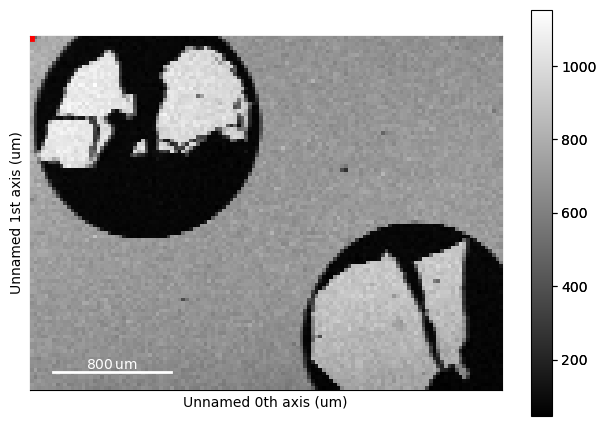

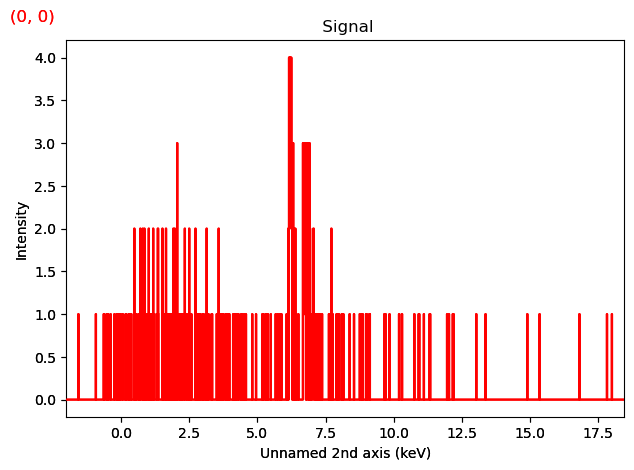

In [25]:
s.plot()

In [27]:
s.axes_manager

Navigation axis name,size,index,offset,scale,units
,128,0,0.0,25.105676651000977,um
,96,0,0.0,25.105676651000977,um
Signal axis name,size,,offset,scale,units
,2048,,-2.0155010986328126,0.01,keV
